# Preparing microarray data

In [5]:
import sys
sys.path.append("../")

from config import *

In [6]:
receptor_names = ['5HT1A', '5HT1B', '5HT2A', '5HT4', '5HTT']
tracer_names = ['cumi101', 'az10419369', 'cimbi36', 'sb207145', 'dasb']
gene_symbols = ['HTR1A', 'HTR1B', 'HTR2A', 'HTR4', 'SLC6A4']

In [7]:
import pandas as pd
mappings = pd.DataFrame([receptor_names, tracer_names, gene_symbols], index = ['receptor', 'tracer', 'gene']).T
mappings.to_csv(projdir + '/data/beliveau2017_serotonergic_names_mappings.csv')

In [23]:
import abagen
import os
os.environ['ABAGEN_DATA'] = projdir + "/data/ahba/"

donor_ids = ['10021', '12876', '14380', '15496', '15697', '9861']
cic_ids = ['H0351.1009', 'H0351.1012', 'H0351.1015', 'H0351.1016', 'H0351.2001', 'H0351.2002']

map_to_cic = {'10021': 'H0351.2002', \
              '12876': 'H0351.1009', \
              '14380': 'H0351.1012', \
              '15496': 'H0351.1015', \
              '15697': 'H0351.1016', \
              '9861': 'H0351.2001'}

* Update probe coordinates

In [29]:
microarray = abagen.fetch_microarray(donors = donor_ids)

In [37]:
import os

datadir = os.environ.get('ABAGEN_DATA') + '/microarray/'

for donor_id in donor_ids:
    _src = datadir + f"/normalized_microarray_donor{donor_id}/"
    os.rename(_src + "SampleAnnot.csv", _src + "SampleAnnot_original.csv")

In [39]:
for donor_id in donor_ids:
    df0 = pd.read_csv(datadir + f'/normalized_microarray_donor{donor_id}/SampleAnnot_original.csv')
    df1 = pd.read_csv(projdir + f'/data/yee_transformed-points/{map_to_cic[donor_id]}_SampleAnnot_RAS_mni_nonlin.csv')

    df0['mni_x'] = df1['mni_nlin_x']
    df0['mni_y'] = df1['mni_nlin_y']
    df0['mni_z'] = df1['mni_nlin_z']

    df0.to_csv(datadir + f'/normalized_microarray_donor{donor_id}/SampleAnnot.csv')

In [ ]:
import abagen
import os

e, m = abagen.get_samples_in_mask(mask=None, \
                                  corrected_mni=False, \
                                  lr_mirror = None, \
                                  ibf_threshold=0.1)

* Filter probes in left cortex

In [5]:
for donor_id in donor_ids:
    df0 = pd.read_csv(datadir + f'/cic_coords_microarray/microarray/normalized_microarray_donor{donor_id}/SampleAnnot_original.csv')
    df1 = pd.read_csv(datadir + f'cic_coords_microarray/cic_coords/AllenHumanGeneMNI/transformed-points/{map_to_cic[donor_id]}_SampleAnnot_RAS_mni_nonlin.csv')

    df0['mni_x'] = df1['mni_nlin_x']
    df0['mni_y'] = df1['mni_nlin_y']
    df0['mni_z'] = df1['mni_nlin_z']

    df0[ df0['slab_type'] == 'CX' ].to_csv(datadir + f'/cic_coords_microarray/microarray/normalized_microarray_donor{donor_id}/SampleAnnot.csv')

In [23]:
import abagen
import os

os.environ['ABAGEN_DATA'] = '/home/yzhou/projects/interpolate/data/cic_coords_microarray/'
e, m = abagen.get_samples_in_mask(mask=None, \
                                  corrected_mni=False, \
                                  lr_mirror = None, \
                                  data_dir = '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/',\
                                  ibf_threshold=0.1)

{'9861': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor9861/SampleAnnot.csv', '10021': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor10021/SampleAnnot.csv', '12876': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor12876/SampleAnnot.csv', '14380': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor14380/SampleAnnot.csv', '15496': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor15496/SampleAnnot.csv', '15697': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor15697/SampleAnnot.csv'}
                   x          y          z
594         5.655803 -26.155168  51.384257
2985       29.543445  17.026195  -6.486713
2801       29.696883 -19.278341  15.007620
2273      -26.031307 -20.993209  -0.2

In [29]:
left_probes_ind = np.where( m.to_numpy()[:, 0] < 0 )[0]

In [39]:
left_gene_expr = e.loc[m.index[left_probes_ind]]
left_mni_coords = m.loc[m.index[left_probes_ind]]

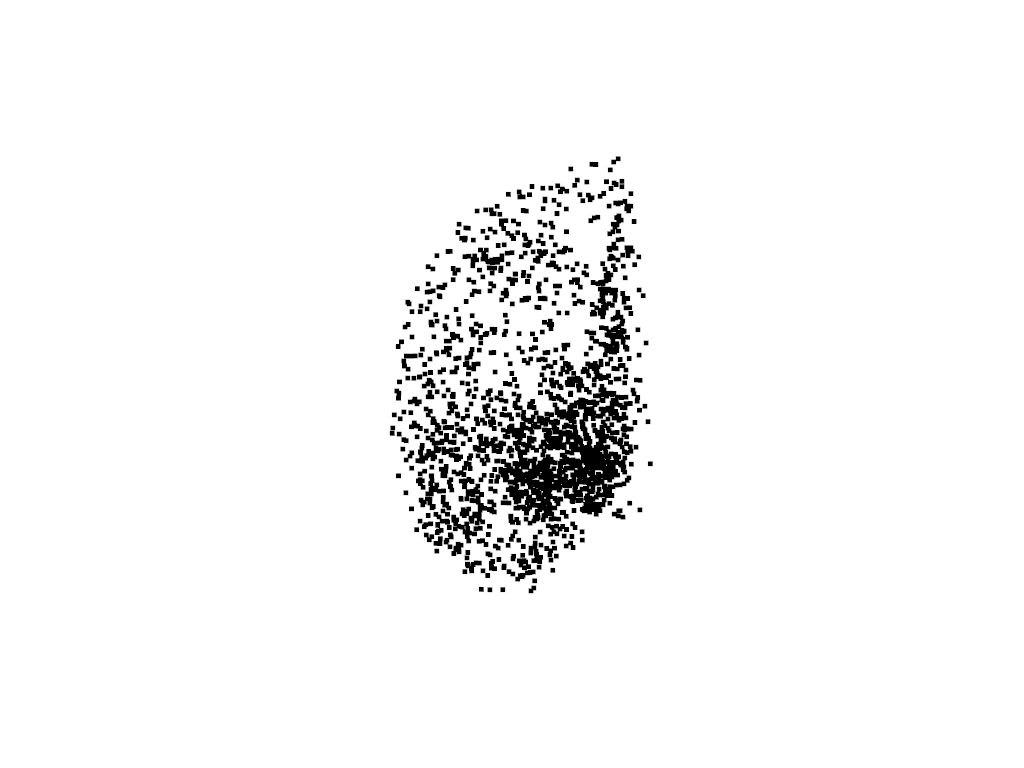

In [40]:
import pyvista as pv
import numpy as np
pl = pv.Plotter()

pl.add_points(m.to_numpy()[left_probes_ind], color = 'k')
pl.camera_position = 'xz'
pl.show(jupyter_backend='static')

In [41]:
import joblib

joblib.dump((left_gene_expr, left_mni_coords), '/home/yzhou/gitrepo/interpolate/data/abagen_get_samples_in_mask_left-cx_ibf-01_coords-cic.pkl')

['/home/yzhou/gitrepo/interpolate/data/abagen_get_samples_in_mask_left-cx_ibf-01_coords-cic.pkl']

# load abagen data

In [22]:
e,m = joblib.load('/home/yzhou/gitrepo/interpolate/data/abagen_get_samples_in_mask_ibf-01_coords-cic.pkl')

In [23]:
# initiate a new dataframe to compile the expressions and then save it

serotonergic = pd.DataFrame([None])

for gene_symbol in gene_symbols:

    if serotonergic.empty: serotonergic = e[gene_symbol]
    else: serotonergic = pd.concat([ serotonergic, e[gene_symbol] ], axis = 1)

serotonergic = serotonergic.drop(0, axis = 0)
serotonergic = serotonergic.drop(0, axis = 1)

In [24]:
serotonergic

,HTR1A,HTR1B,HTR2A,HTR4,SLC6A4
594,0.535725,0.626895,0.820328,0.614966,0.069582
2985,0.582408,0.740827,0.744289,0.561485,0.377521
2801,0.444434,0.617993,0.358410,0.183968,0.896657
2273,0.153231,0.707619,0.151277,0.119202,0.692482
2785,0.529715,0.454390,0.375179,0.717376,0.594159
...,...,...,...,...,...
159439039,0.492662,0.908513,0.376610,0.567687,0.074533
159438991,0.132141,1.000000,0.478848,0.135214,0.511235
159438975,0.116330,0.183857,0.456828,0.030026,0.750181
159438959,0.064028,0.176525,0.353386,0.201005,0.105511


In [25]:
joblib.dump((serotonergic,m), '/home/yzhou/gitrepo/interpolate/data/abagen_ibf-01_serotonergic_gene_expression.pkl')

['/home/yzhou/gitrepo/interpolate/data/abagen_ibf-01_serotonergic_gene_expression.pkl']

# Set up src_polydata that contains genes to interpolate and covariate PET maps sampled at the same coordinates

In [26]:
import joblib
import pyvista as pv

e,m = joblib.load('/home/yzhou/gitrepo/interpolate/data/abagen_ibf-01_serotonergic_gene_expression.pkl')


In [27]:
microarray = pv.PolyData(m.to_numpy())
for gene_symbol in gene_symbols:
    microarray['mrna_' + gene_symbol] = e[gene_symbol]

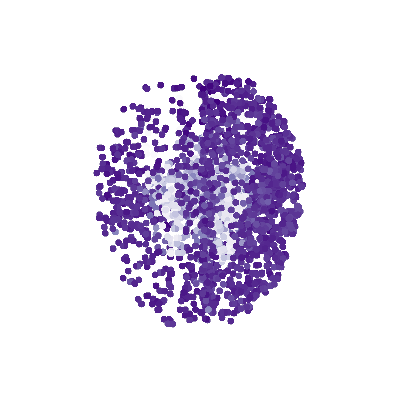

In [28]:
pl = pv.Plotter(lighting = 'three lights', window_size = (400,400))

points_aes = {"show_scalar_bar": False,\
            "render_points_as_spheres": True,\
            "point_size": 7,\
            "specular": 0, "diffuse":0, "ambient":1}

pl.add_points(microarray.rotate_z(180), cmap = 'Purples', scalars = 'mrna_HTR2A', **points_aes)
pl.camera_position = 'xy'
pl.show(jupyter_backend = 'static')

In [29]:
import joblib
import nibabel as nb
from nibabel.affines import apply_affine
import numpy as np
import numpy.linalg as npl
import os
from scipy.ndimage import map_coordinates

reregistered_pet_dir = '/home/yzhou/projects/out_2009c/'

fnames = os.listdir(reregistered_pet_dir)

for fname in fnames:
    PET = nb.load(reregistered_pet_dir + fname)

    sourcetag = fname.split('_')[0].split('-')[1]
    desctag = fname.split('_')[1].split('-')[1]

    maptag = f'pet_{sourcetag}_{desctag}'

    points = microarray.points
    img_data = PET.get_fdata()
    inverse_aff = npl.inv(PET.affine)
    ijk_points = apply_affine(inverse_aff, points)

    vals = np.zeros(microarray.n_points)
    for pi in range(points.shape[0]):
        
        vox_value = map_coordinates(img_data, ijk_points[pi,:].reshape(-1,1), order=1)
        vals[pi] = vox_value[0]
        
    microarray[maptag] = vals

In [30]:
joblib.dump(microarray, '/home/yzhou/gitrepo/interpolate/data/icbm09c_cic-volume_microarray-pet.pkl')

['/home/yzhou/gitrepo/interpolate/data/icbm09c_cic-volume_microarray-pet.pkl']

## load interpolated maps and compare with PET


In [4]:
import joblib
projdir = '/home/yzhou/gitrepo/interpolate/'

probes = joblib.load( projdir + '/data/icbm09c_left-volume_microarray-pet.pkl' )

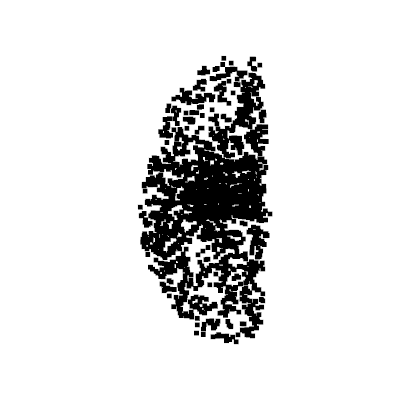

In [7]:
import pyvista as pv
pl = pv.Plotter(window_size = (400,400))

pl.add_points(probes, color = 'k')
pl.camera_position = 'xy'
pl.show(jupyter_backend = 'static')